In [1]:
!git clone https://github.com/quark28/miniml.git
%cd miniml

Cloning into 'miniml'...
remote: Enumerating objects: 42, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 42 (delta 15), reused 38 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (42/42), 15.28 KiB | 489.00 KiB/s, done.
Resolving deltas: 100% (15/15), done.
/content/miniml


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression as SklearnLR, Ridge as SklearnRidge, Lasso as SklearnLasso
from sklearn.datasets import load_diabetes, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from miniml.linear_regression import LinearRegression

In [7]:
np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)

In [8]:
N, D = 1000, 5
X_synth = np.random.randn(N, D)
true_w = np.array([3.0, -2.0, 0.5, 1.5, -1.0])
true_bias = 4.0
y_synth = X_synth @ true_w + true_bias + np.random.randn(N) * 0.5

X_train, X_test, y_train, y_test = train_test_split(X_synth, y_synth, test_size=0.2, random_state=42)

print(f"{N} объектов, {D} признаков")
print(f"Истинные веса: {true_w}, bias: {true_bias}")

1000 объектов, 5 признаков
Истинные веса: [ 3.  -2.   0.5  1.5 -1. ], bias: 4.0


In [9]:
diabetes = load_diabetes()
X_diab, y_diab = diabetes.data, diabetes.target

scaler = StandardScaler()
X_diab_scaled = scaler.fit_transform(X_diab)

X_diab_train, X_diab_test, y_diab_train, y_diab_test = train_test_split(
    X_diab_scaled, y_diab, test_size=0.2, random_state=42
)

print(f"Diabetes dataset: {X_diab.shape[0]} объектов, {X_diab.shape[1]} признаков")

Diabetes dataset: 442 объектов, 10 признаков


In [10]:
methods = [
    ('analytic (classic)', dict(learning_type='as', ad_type='classic')),
    ('analytic (svd)',     dict(learning_type='as', ad_type='svd')),
    ('gd',                 dict(learning_type='gd', n_steps=3000, lr=0.05, lr_type='constant')),
    ('sgd',                dict(learning_type='sgd', n_steps=8000, lr=0.01, lr_type='constant', batch_size=32)),
    ('sag',                dict(learning_type='sag', n_steps=3000, lr=0.01, lr_type='constant', batch_size=16)),
    ('momentum',           dict(learning_type='mm', n_steps=3000, lr=0.05, lr_type='constant', gamma=0.9)),
    ('nesterov',           dict(learning_type='nag', n_steps=3000, lr=0.05, lr_type='constant', gamma=0.9)),
    ('rmsprop',            dict(learning_type='rms', n_steps=3000, lr=0.05, lr_type='constant', alpha=0.9, const=1e-8)),
    ('adadelta',           dict(learning_type='adadelta', n_steps=3000, lr=1.0, lr_type='constant', alpha=0.9, const=1e-8)),
    ('adam',               dict(learning_type='adam', n_steps=3000, lr=0.05, lr_type='constant', gamma=0.9, alpha=0.999, const=1e-8)),
    ('nadam',              dict(learning_type='nadam', n_steps=3000, lr=0.05, lr_type='constant', gamma=0.9, alpha=0.999, const=1e-8)),
    ('adagrad',            dict(learning_type='adagrad', n_steps=3000, lr=0.5, lr_type='constant', const=1e-8)),
]

results = []

sk_model = SklearnLR()
sk_model.fit(X_train, y_train)
sk_pred = sk_model.predict(X_test)
sk_mse = mean_squared_error(y_test, sk_pred)
sk_r2 = r2_score(y_test, sk_pred)
results.append(('sklearn', sk_mse, sk_r2, sk_model.coef_.copy(), sk_model.intercept_))

for name, kwargs in methods:
    model = LinearRegression(loss='mse')
    model.fit(X_train, y_train, **kwargs)
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    results.append((name, mse, r2, model.coefficients.copy(), model.bias))

df_results = pd.DataFrame(
    [(name, mse, r2) for name, mse, r2, _, _ in results],
    columns=['method', 'MSE', 'R2']
)
print(df_results.to_string(index=False))

            method       MSE       R2
           sklearn  0.243723 0.984203
analytic (classic)  0.243723 0.984203
    analytic (svd)  0.243723 0.984203
                gd  0.243723 0.984203
               sgd  0.246517 0.984021
               sag  0.243723 0.984203
          momentum  0.243723 0.984203
          nesterov  0.243723 0.984203
           rmsprop  0.245396 0.984094
          adadelta 13.149010 0.147715
              adam  0.243723 0.984203
             nadam  0.246599 0.984016
           adagrad  0.243723 0.984203


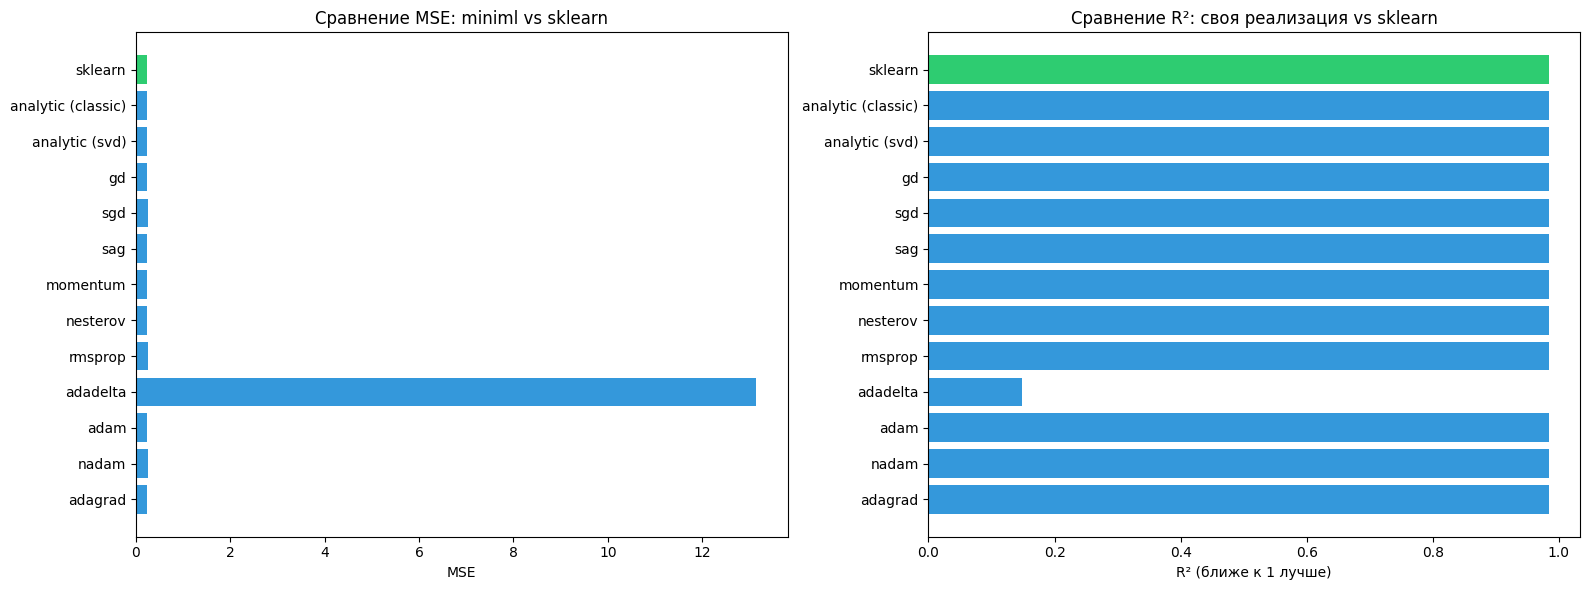

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#2ecc71' if r[0] == 'sklearn' else '#3498db' for r in results]
axes[0].barh(df_results['method'], df_results['MSE'], color=colors)
axes[0].set_xlabel('MSE')
axes[0].set_title('Сравнение MSE: miniml vs sklearn')
axes[0].invert_yaxis()

axes[1].barh(df_results['method'], df_results['R2'], color=colors)
axes[1].set_xlabel('R² (ближе к 1 лучше)')
axes[1].set_title('Сравнение R²: своя реализация vs sklearn')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('comparison_synthetic.png', dpi=100)
plt.show()

            method  weight_diff_from_sklearn
              adam              1.155112e-15
          nesterov              1.195747e-15
          momentum              1.195747e-15
analytic (classic)              2.465095e-15
                gd              3.202854e-15
           adagrad              4.616446e-15
    analytic (svd)              1.226482e-14
               sag              3.114264e-12
             nadam              2.472861e-02
               sgd              2.866760e-02
           rmsprop              5.590169e-02
          adadelta              2.058035e+00


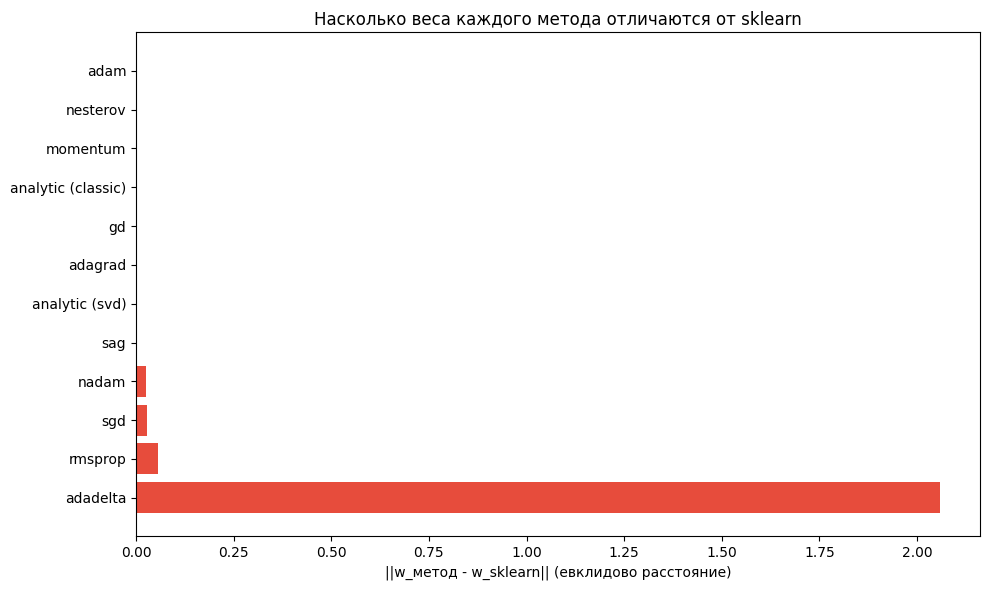

In [14]:
sklearn_coef = results[0][3]
sklearn_bias = results[0][4]

weight_diffs = []
for name, mse, r2, coef, bias in results[1:]:
    diff = np.linalg.norm(coef - sklearn_coef)
    weight_diffs.append((name, diff))

df_diffs = pd.DataFrame(weight_diffs, columns=['method', 'weight_diff_from_sklearn'])
df_diffs = df_diffs.sort_values('weight_diff_from_sklearn')
print(df_diffs.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(df_diffs['method'], df_diffs['weight_diff_from_sklearn'], color='#e74c3c')
plt.xlabel('||w_метод - w_sklearn|| (евклидово расстояние)')
plt.title('Насколько веса каждого метода отличаются от sklearn')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('weight_diffs.png', dpi=100)
plt.show()

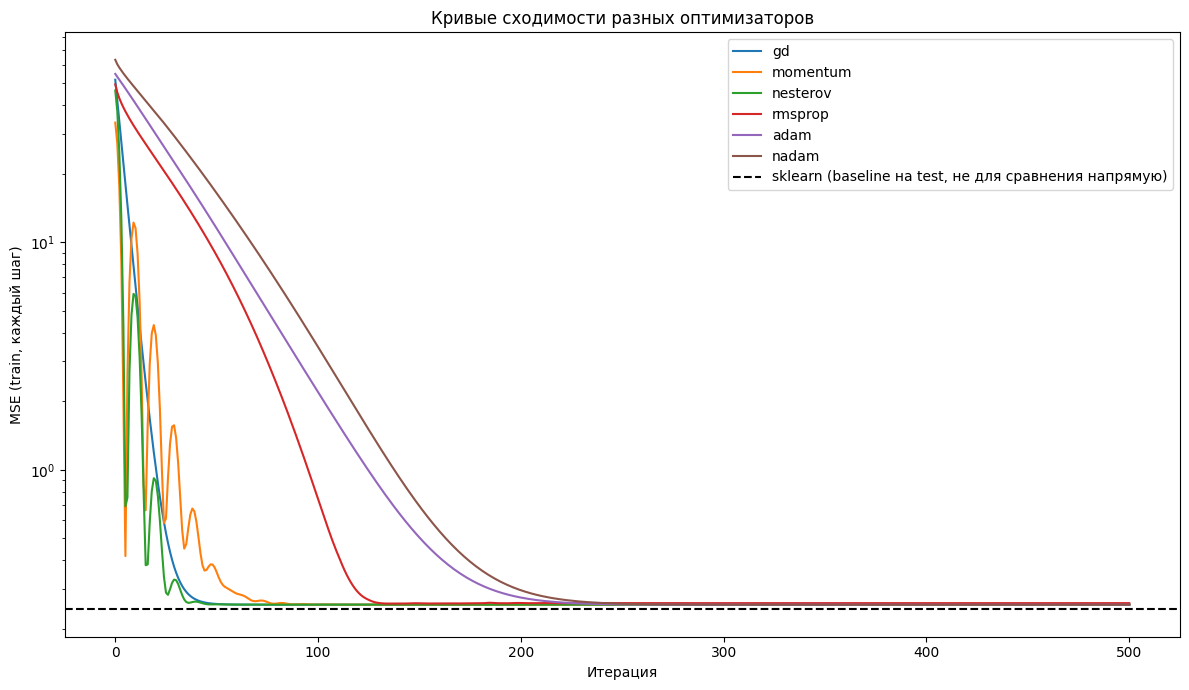

In [15]:
def fit_with_history(model, X, y, **kwargs):
    history = []
    original_loss_func = model.loss_func

    def logging_loss_func(y_pred, y_true):
        val = original_loss_func(y_pred, y_true)
        history.append(val)
        return val

    model.loss_func = logging_loss_func
    model.fit(X, y, **kwargs)
    model.loss_func = original_loss_func
    return history


gd_methods_to_plot = [
    ('gd',       dict(learning_type='gd', n_steps=500, lr=0.05, lr_type='constant')),
    ('momentum', dict(learning_type='mm', n_steps=500, lr=0.05, lr_type='constant', gamma=0.9)),
    ('nesterov', dict(learning_type='nag', n_steps=500, lr=0.05, lr_type='constant', gamma=0.9)),
    ('rmsprop',  dict(learning_type='rms', n_steps=500, lr=0.05, lr_type='constant', alpha=0.9, const=1e-8)),
    ('adam',     dict(learning_type='adam', n_steps=500, lr=0.05, lr_type='constant', gamma=0.9, alpha=0.999, const=1e-8)),
    ('nadam',    dict(learning_type='nadam', n_steps=500, lr=0.05, lr_type='constant', gamma=0.9, alpha=0.999, const=1e-8)),
]

plt.figure(figsize=(12, 7))
for name, kwargs in gd_methods_to_plot:
    model = LinearRegression(loss='mse')
    history = fit_with_history(model, X_train, y_train, **kwargs)
    plt.plot(history, label=name)

plt.axhline(y=sk_mse, color='black', linestyle='--', label='sklearn (baseline на test, не для сравнения напрямую)')
plt.xlabel('Итерация')
plt.ylabel('MSE (train, каждый шаг)')
plt.title('Кривые сходимости разных оптимизаторов')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.savefig('convergence_curves.png', dpi=100)
plt.show()

=== Diabetes dataset ===
Method                      MSE
sklearn Ridge           2892.03
my Ridge                2892.03
sklearn Lasso           2884.55
my Lasso                2891.50


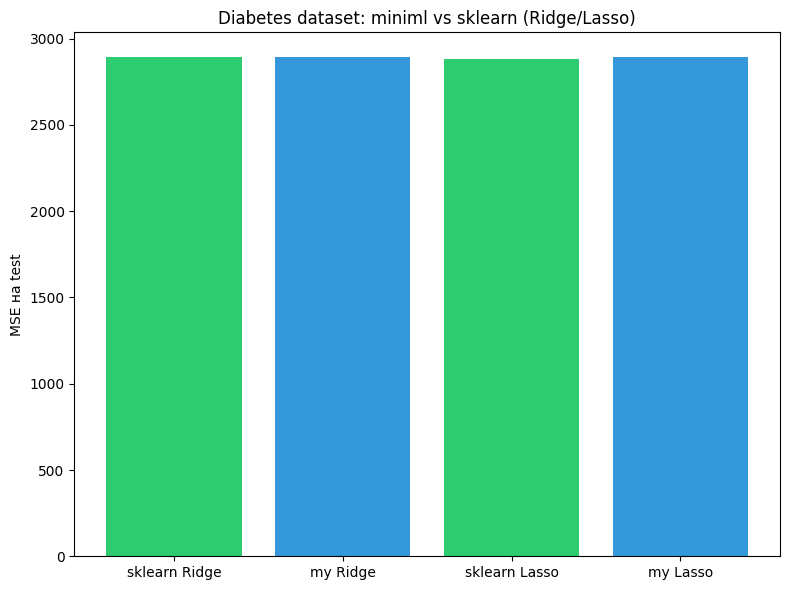

In [16]:
sk_ridge = SklearnRidge(alpha=1.0)
sk_ridge.fit(X_diab_train, y_diab_train)
sk_ridge_pred = sk_ridge.predict(X_diab_test)
sk_ridge_mse = mean_squared_error(y_diab_test, sk_ridge_pred)

sk_lasso = SklearnLasso(alpha=0.1)
sk_lasso.fit(X_diab_train, y_diab_train)
sk_lasso_pred = sk_lasso.predict(X_diab_test)
sk_lasso_mse = mean_squared_error(y_diab_test, sk_lasso_pred)

my_ridge = LinearRegression(loss='mse', regularizator='ridge', alpha=1.0)
my_ridge.fit(X_diab_train, y_diab_train, learning_type='as', ad_type='svd')
my_ridge_pred = my_ridge.predict(X_diab_test)
my_ridge_mse = mean_squared_error(y_diab_test, my_ridge_pred)

my_lasso = LinearRegression(loss='mse', regularizator='lasso', alpha=0.1)
my_lasso.fit(X_diab_train, y_diab_train, learning_type='gd', n_steps=5000, lr=0.05, lr_type='constant')
my_lasso_pred = my_lasso.predict(X_diab_test)
my_lasso_mse = mean_squared_error(y_diab_test, my_lasso_pred)

print("=== Diabetes dataset ===")
print(f"{'Method':<20} {'MSE':>10}")
print(f"{'sklearn Ridge':<20} {sk_ridge_mse:>10.2f}")
print(f"{'my Ridge':<20} {my_ridge_mse:>10.2f}")
print(f"{'sklearn Lasso':<20} {sk_lasso_mse:>10.2f}")
print(f"{'my Lasso':<20} {my_lasso_mse:>10.2f}")

plt.figure(figsize=(8, 6))
names = ['sklearn Ridge', 'my Ridge', 'sklearn Lasso', 'my Lasso']
values = [sk_ridge_mse, my_ridge_mse, sk_lasso_mse, my_lasso_mse]
colors = ['#2ecc71', '#3498db', '#2ecc71', '#3498db']
plt.bar(names, values, color=colors)
plt.ylabel('MSE на test')
plt.title('Diabetes dataset: miniml vs sklearn (Ridge/Lasso)')
plt.tight_layout()
plt.savefig('diabetes_comparison.png', dpi=100)
plt.show()

Ближайший к sklearn метод по весам: adam


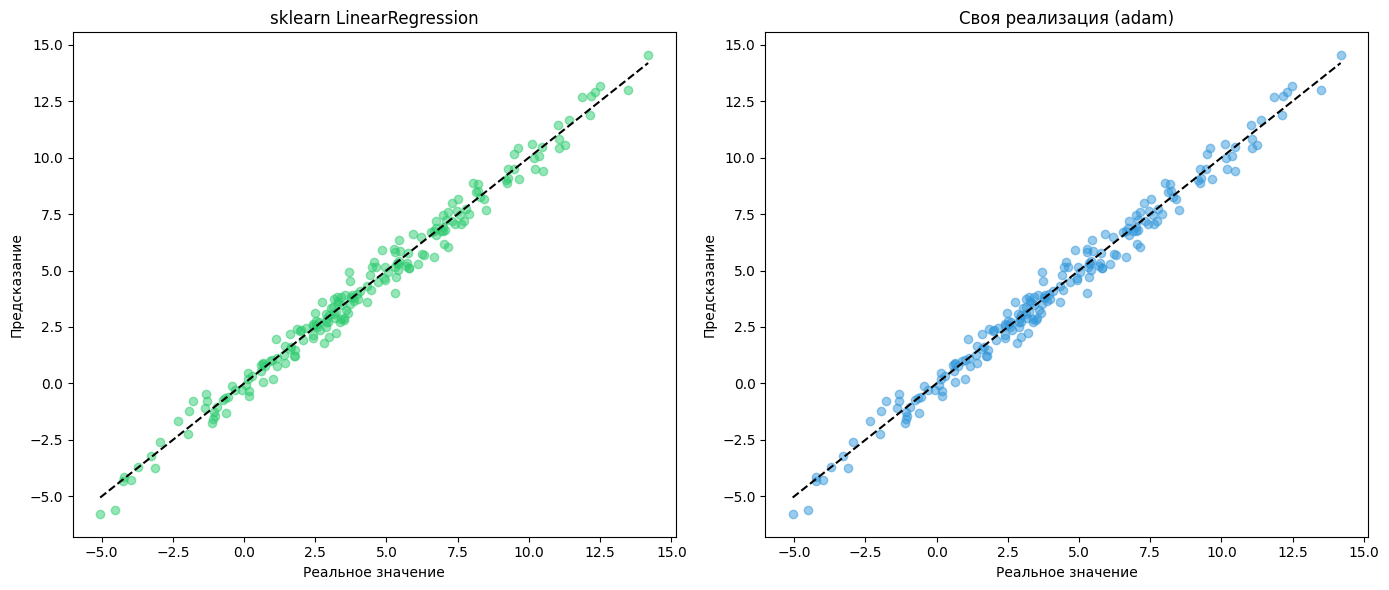

In [17]:
best_method_name = df_diffs.iloc[0]['method']
print(f"Ближайший к sklearn метод по весам: {best_method_name}")

best_model = LinearRegression(loss='mse')
best_kwargs = dict(methods)[best_method_name]
best_model.fit(X_train, y_train, **best_kwargs)
best_pred = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, sk_pred, alpha=0.5, color='#2ecc71')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
axes[0].set_xlabel('Реальное значение')
axes[0].set_ylabel('Предсказание')
axes[0].set_title('sklearn LinearRegression')

axes[1].scatter(y_test, best_pred, alpha=0.5, color='#3498db')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
axes[1].set_xlabel('Реальное значение')
axes[1].set_ylabel('Предсказание')
axes[1].set_title(f'Своя реализация ({best_method_name})')

plt.tight_layout()
plt.savefig('predictions_scatter.png', dpi=100)
plt.show()

In [18]:
print(f"sklearn MSE (test):      {sk_mse:.6f}")
print(f"Лучший свой метод:       {df_diffs.iloc[0]['method']}")
print(f"Разница в весах:         {df_diffs.iloc[0]['weight_diff_from_sklearn']:.6f}")

sklearn MSE (test):      0.243723
Лучший свой метод:       adam
Разница в весах:         0.000000
